# NEOCP VDP Comparison

Score real NEOCP objects from the live archive against VDP probability maps and compare
with MPC-published scores. Three outputs:
1. **Sky coverage** — which collected objects fall in the VDP map footprint
2. **ECDF** — cumulative score distributions (VDP vs MPC)
3. **Score time series** — how MPC score and VDP P_NEO evolved per designation

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.abspath('.'), 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
from pathlib import Path

import velocity_density_pipeline as vdp

BASE   = Path('neocp_data')
MAPDIR = Path('prob_maps')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

## 1. Load data

In [2]:
obj  = pd.read_csv(BASE / 'tables/neocp_objects_history.csv',
                   parse_dates=['fetched_at_utc'])
eph  = pd.read_csv(BASE / 'tables/neocp_ephemerides_history.csv',
                   parse_dates=['fetched_at_utc', 'ephem_time_utc'])
runs = pd.read_csv(BASE / 'tables/neocp_runs.csv',
                   parse_dates=['started_at_utc', 'finished_at_utc'])

print(f'Runs:        {len(runs):,} total, {(runs.status=="ok").sum():,} ok')
print(f'Objects:     {len(obj):,} rows, {obj.designation.nunique()} unique designations')
print(f'Ephemerides: {len(eph):,} rows')
print(f'Date range:  {obj.fetched_at_utc.min().date()} → {obj.fetched_at_utc.max().date()}')
print()
print('MPC score_0_1 distribution (all snapshots):')
print(obj.score_0_1.describe().round(3))
print()
print('Top designations by snapshot count:')
print(obj.designation.value_counts().head(10).to_string())

Runs:        470 total, 469 ok
Objects:     12,927 rows, 279 unique designations
Ephemerides: 300,875 rows
Date range:  2026-05-09 → 2026-06-01

MPC score_0_1 distribution (all snapshots):
count    12927.000
mean         0.871
std          0.229
min          0.100
25%          0.850
50%          0.990
75%          1.000
max          1.000
Name: score_0_1, dtype: float64

Top designations by snapshot count:
designation
P12neKs    288
CEMVK32    278
KPMa1Ih    248
NAOCAN7    238
C1EUYV5    235
P12nfaz    217
S001563    209
ST26EC8    202
NAOCBPP    169
ST26E75    155


## 2. Motion decomposition

MPC ephemerides give total sky speed `motion_arcsec_per_min` and position angle `pa_deg`
(N through E). Decompose into coordinate rates `dra_deg_day` and `ddec_deg_day`.

MPC convention: `motion * sin(PA)` is the angular rate in the RA direction,
equal to `dα/dt * cos(δ)`. The cos(dec) correction gives the actual coordinate rate.

In [3]:
conv = (60.0 * 24.0) / 3600.0   # arcsec/min → deg/day

eph = eph.copy()
pa_rad  = np.deg2rad(eph['pa_deg'])
dec_rad = np.deg2rad(eph['dec_deg'])
cos_dec = np.cos(dec_rad)

eph['ddec_deg_day'] = eph['motion_arcsec_per_min'] * np.cos(pa_rad) * conv
eph['dra_deg_day']  = (eph['motion_arcsec_per_min'] * np.sin(pa_rad)
                        / np.where(np.abs(cos_dec) > 1e-6, cos_dec, np.nan)
                        * conv)

# Flag pathological rows
eph['rate_ok'] = (
    np.isfinite(eph['dra_deg_day']) &
    np.isfinite(eph['ddec_deg_day']) &
    (eph['motion_arcsec_per_min'] < 10_000)   # drop obvious outliers
)
print(f'Rate-ok rows: {eph.rate_ok.sum():,} / {len(eph):,} '
      f'({eph.rate_ok.mean():.1%})')

Rate-ok rows: 300,870 / 300,875 (100.0%)


## 3. Select contemporaneous ephemeris per snapshot

Each (designation, snapshot_id) pair has 25 hourly ephemeris rows. Pick the row
whose `ephem_time_utc` is closest to `fetched_at_utc` — this gives the most
contemporaneous sky position for scoring.

In [4]:
obj_times = obj[['designation', 'snapshot_id', 'fetched_at_utc']].copy()
eph_m = eph[eph['rate_ok']].merge(obj_times, on=['designation', 'snapshot_id'])

eph_m['dt_sec'] = (
    (eph_m['ephem_time_utc'] - eph_m['fetched_at_utc_y'])
    .dt.total_seconds().abs()
)

eph_near = (
    eph_m.sort_values('dt_sec')
         .groupby(['designation', 'snapshot_id'], as_index=False)
         .first()
         .reset_index(drop=True)
)

print(f'Scoring input: {len(eph_near):,} rows '
      f'({eph_near.designation.nunique()} unique designations)')

Scoring input: 12,035 rows (278 unique designations)


## 4. Load maps and assign footprints

Use only the monthly antisun maps (wide grid −1.5 to +1.5 deg/day). For each
observation row, find the map whose centre is within 30° AND whose obstime is
closest to the observation epoch. Objects outside all footprints are flagged as
unscored.

Footprint check uses a fast manual equatorial → ecliptic rotation so there is no
per-row astropy overhead.

In [5]:
# ── helpers ──────────────────────────────────────────────────────────────────
OBLIQUITY_RAD = np.deg2rad(23.439291)
_c, _s = np.cos(OBLIQUITY_RAD), np.sin(OBLIQUITY_RAD)

def radec_to_ecl(ra_deg, dec_deg):
    """Fast vectorized equatorial → ecliptic (fixed obliquity). Returns lon, lat in deg."""
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    x = np.cos(dec) * np.cos(ra)
    y = np.cos(dec) * np.sin(ra)
    z = np.sin(dec)
    y_ecl =  _c * y + _s * z
    z_ecl = -_s * y + _c * z
    lon = np.rad2deg(np.arctan2(y_ecl, x)) % 360.0
    lat = np.rad2deg(np.arcsin(np.clip(z_ecl, -1.0, 1.0)))
    return lon, lat

def ang_sep_deg(lon1, lat1, lon2, lat2):
    """Vectorized angular separation between (lon1,lat1) and scalar (lon2,lat2), degrees."""
    l1, b1 = np.deg2rad(lon1), np.deg2rad(lat1)
    l2, b2 = float(np.deg2rad(lon2)), float(np.deg2rad(lat2))
    return np.rad2deg(np.arccos(np.clip(
        np.sin(b1)*np.sin(b2) + np.cos(b1)*np.cos(b2)*np.cos(l1 - l2), -1.0, 1.0)))

# ── load maps ─────────────────────────────────────────────────────────────────
map_files = sorted(MAPDIR.glob('prob_maps_*_antisun.npz'))
print(f'Loading {len(map_files)} antisun maps...')
map_meta = []
for f in map_files:
    pms = vdp.ProbMapSet.from_npz(str(f))
    obstime_mjd = (
        pd.Timestamp(pms.obstime_str, tz='UTC').to_julian_date() - 2400000.5
    )
    map_meta.append({
        'name':           f.stem,
        'pms':            pms,
        'obstime_mjd':    obstime_mjd,
        'center_lon_deg': pms.center_lon_deg,
        'center_lat_deg': pms.center_lat_deg,
        'max_sep_deg':    pms.max_sep_deg,
    })
print(f'  grid range: {pms.x_grid[0]:.1f} to {pms.x_grid[-1]:.1f} deg/day '
      f'({len(pms.x_grid)} points)')

# ── compute ecliptic coords for all scoring rows ───────────────────────────
ecl_lon, ecl_lat = radec_to_ecl(
    eph_near['ra_deg'].to_numpy(), eph_near['dec_deg'].to_numpy())

obs_mjd = (
    eph_near['ephem_time_utc']
    .apply(lambda t: t.to_julian_date() - 2400000.5)
    .to_numpy()
)

eph_near = eph_near.copy()
eph_near['ecl_lon'] = ecl_lon
eph_near['ecl_lat'] = ecl_lat

# ── assign best map per row ────────────────────────────────────────────────
eph_near['map_used'] = None
eph_near['best_dt']  = np.inf

for md in map_meta:
    sep = ang_sep_deg(ecl_lon, ecl_lat, md['center_lon_deg'], md['center_lat_deg'])
    dt  = np.abs(obs_mjd - md['obstime_mjd'])
    update = (sep <= md['max_sep_deg']) & (dt < eph_near['best_dt'].to_numpy())
    eph_near.loc[update, 'map_used'] = md['name']
    eph_near.loc[update, 'best_dt']  = dt[update]

eph_near['in_footprint'] = eph_near['map_used'].notna()
n_fp = eph_near['in_footprint'].sum()
print(f'\nIn footprint: {n_fp:,} / {len(eph_near):,} rows ({n_fp/len(eph_near):.1%})')
print(f'Unique designations in footprint: '
      f'{eph_near[eph_near.in_footprint].designation.nunique()}')
print()
print('Maps used (top 10):')
print(eph_near['map_used'].value_counts().head(10).to_string())

Loading 24 antisun maps...
  grid range: -1.5 to 1.5 deg/day (301 points)

In footprint: 8,394 / 12,035 rows (69.7%)
Unique designations in footprint: 203

Maps used (top 10):
map_used
prob_maps_2026-06-01_antisun    3372
prob_maps_2026-05-01_antisun    2956
prob_maps_2026-08-01_antisun     689
prob_maps_2026-07-01_antisun     350
prob_maps_2026-09-01_antisun     346
prob_maps_2026-10-01_antisun     230
prob_maps_2026-04-01_antisun     206
prob_maps_2026-03-01_antisun     133
prob_maps_2026-11-01_antisun     105
prob_maps_2026-01-01_antisun       3


## 5. VDP scoring

Score all in-footprint rows against their assigned map in batches.
`score_observation` returns a dict `{population: P_NEO_array}`. We take the NEO
component. Objects outside the velocity grid (|vlam| or |vbeta| > 1.5 deg/day)
receive P_NEO = 0.

In [6]:
eph_near['P_NEO_vdp'] = np.nan
eph_near['vlam']      = np.nan
eph_near['vbeta']     = np.nan

map_dict = {md['name']: md['pms'] for md in map_meta}

for map_name, pms in map_dict.items():
    mask = eph_near['map_used'] == map_name
    if not mask.any():
        continue
    sub = eph_near.loc[mask]
    result = pms.score_observation(
        ra_deg       = sub['ra_deg'].to_numpy(),
        dec_deg      = sub['dec_deg'].to_numpy(),
        dra_deg_day  = sub['dra_deg_day'].to_numpy(),
        ddec_deg_day = sub['ddec_deg_day'].to_numpy(),
        mag_app      = sub['v_mag'].to_numpy(),
        scorer       = None,
        return_intermediates = True,
    )
    eph_near.loc[mask, 'P_NEO_vdp'] = result['probs']['NEO']
    eph_near.loc[mask, 'vlam']      = result['vlam']
    eph_near.loc[mask, 'vbeta']     = result['vbeta']
    print(f'  {map_name}: {mask.sum()} rows scored')

n_scored = eph_near['P_NEO_vdp'].notna().sum()
print(f'\nTotal scored: {n_scored:,}')

  prob_maps_2025-05-01_antisun: 2 rows scored
  prob_maps_2025-06-01_antisun: 1 rows scored
  prob_maps_2026-01-01_antisun: 3 rows scored
  prob_maps_2026-02-01_antisun: 1 rows scored
  prob_maps_2026-03-01_antisun: 133 rows scored
  prob_maps_2026-04-01_antisun: 206 rows scored
  prob_maps_2026-05-01_antisun: 2956 rows scored
  prob_maps_2026-06-01_antisun: 3372 rows scored
  prob_maps_2026-07-01_antisun: 350 rows scored
  prob_maps_2026-08-01_antisun: 689 rows scored
  prob_maps_2026-09-01_antisun: 346 rows scored
  prob_maps_2026-10-01_antisun: 230 rows scored
  prob_maps_2026-11-01_antisun: 105 rows scored

Total scored: 8,394


## 6. Merge and summary

In [7]:

# Drop columns that exist in both obj and eph to avoid _x/_y suffixes after merge:
# ra_deg, dec_deg, v_mag come from obj; elong_deg, ecl_lon/lat, vlam/vbeta are eph-only.
scored_cols = ['designation', 'snapshot_id',
               'ecl_lon', 'ecl_lat',
               'dra_deg_day', 'ddec_deg_day',
               'elong_deg',
               'map_used', 'in_footprint',
               'P_NEO_vdp', 'vlam', 'vbeta']

scored = eph_near[[c for c in scored_cols if c in eph_near.columns]].copy()

final = obj.merge(scored, on=['designation', 'snapshot_id'], how='left')

print(f'Final table: {len(final):,} rows')
print(f'Columns: {list(final.columns)}')
print(f'With VDP score: {final.P_NEO_vdp.notna().sum():,}')
print()

# Per-designation summary using latest snapshot
latest = (
    final.sort_values('fetched_at_utc')
         .groupby('designation', as_index=False)
         .last()
)
print('Per-designation summary (latest snapshot, sorted by VDP score):')
summary_cols = ['designation', 'score_0_1', 'P_NEO_vdp', 'v_mag',
                'nobs', 'arc_days', 'elong_deg', 'map_used']
print(latest[[c for c in summary_cols if c in latest.columns]]
      .sort_values('P_NEO_vdp', ascending=False)
      .to_string(index=False))


Final table: 12,927 rows
Columns: ['snapshot_id', 'fetched_at_utc', 'designation', 'score', 'score_0_1', 'discovery_date_mpc', 'ra_hours', 'ra_deg', 'dec_deg', 'v_mag', 'status', 'updated_mpc', 'note', 'nobs', 'arc_days', 'h_mag', 'not_seen_days', 'source_url', 'ecl_lon', 'ecl_lat', 'dra_deg_day', 'ddec_deg_day', 'elong_deg', 'map_used', 'in_footprint', 'P_NEO_vdp', 'vlam', 'vbeta']
With VDP score: 8,394

Per-designation summary (latest snapshot, sorted by VDP score):
designation  score_0_1  P_NEO_vdp  v_mag  nobs  arc_days  elong_deg                     map_used
    ST26E76       0.74   0.912131   23.2    17      2.00      145.1 prob_maps_2026-05-01_antisun
    P22n4V7       0.84   0.911027   22.0    29      2.05      165.1 prob_maps_2026-05-01_antisun
    P12nc08       1.00   0.865561   21.6     5      0.09      172.0 prob_maps_2026-05-01_antisun
    CZYNHKZ       1.00   0.846350   21.2    14     12.93      157.0 prob_maps_2026-06-01_antisun
    CEM1R02       0.10   0.830085   21.7  

## 7. Sky positions and footprint coverage

RA/Dec scatter of all unique NEOCP objects (latest snapshot). Color = MPC score.
Stars mark objects that received a VDP score. Right panel: elongation distribution.

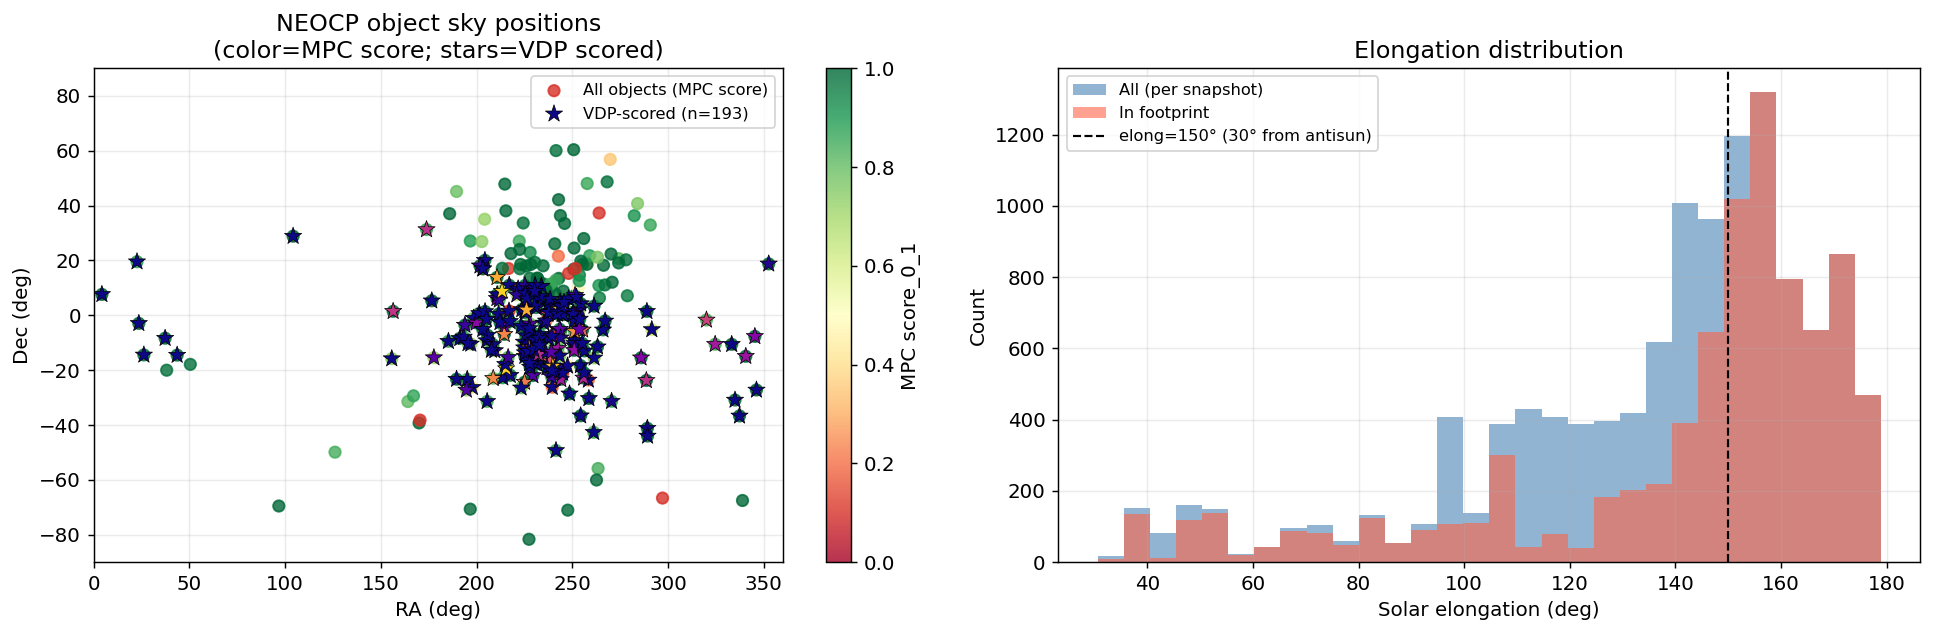

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── left: sky scatter ────────────────────────────────────────────────────────
ax = axes[0]
sc = ax.scatter(
    latest['ra_deg'], latest['dec_deg'],
    c=latest['score_0_1'], cmap='RdYlGn', vmin=0, vmax=1,
    s=40, alpha=0.8, zorder=2, label='All objects (MPC score)',
)
fig.colorbar(sc, ax=ax, label='MPC score_0_1')

# overlay in-footprint
fp = latest[latest['in_footprint'] == True]
ax.scatter(fp['ra_deg'], fp['dec_deg'],
           c=fp['P_NEO_vdp'], cmap='plasma', vmin=0, vmax=1,
           s=100, marker='*', zorder=3, edgecolors='k', linewidths=0.4,
           label=f'VDP-scored (n={len(fp)})')

ax.set_xlabel('RA (deg)'); ax.set_ylabel('Dec (deg)')
ax.set_title('NEOCP object sky positions\n(color=MPC score; stars=VDP scored)')
ax.set_xlim(0, 360); ax.set_ylim(-90, 90)
ax.legend(fontsize=9); ax.grid(alpha=0.25)

# ── right: elongation histogram ───────────────────────────────────────────────
ax2 = axes[1]
elong_all = final['elong_deg'].dropna()
elong_fp  = final.loc[final['in_footprint'] == True, 'elong_deg'].dropna()
ax2.hist(elong_all, bins=30, alpha=0.6, color='steelblue', label='All (per snapshot)')
ax2.hist(elong_fp,  bins=30, alpha=0.6, color='tomato',    label='In footprint')
ax2.axvline(150, color='k', lw=1.2, linestyle='--', label='elong=150° (30° from antisun)')
ax2.set_xlabel('Solar elongation (deg)')
ax2.set_ylabel('Count')
ax2.set_title('Elongation distribution')
ax2.legend(fontsize=9); ax2.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('outputs/neocp_sky_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

## 8. ECDF: VDP P_NEO vs MPC score

Empirical CDF of both scores using the **latest snapshot per designation**.
Left panel uses all designations for MPC; only in-footprint ones for VDP.
Right panel shows the same on a log x-axis to resolve the low-score region.

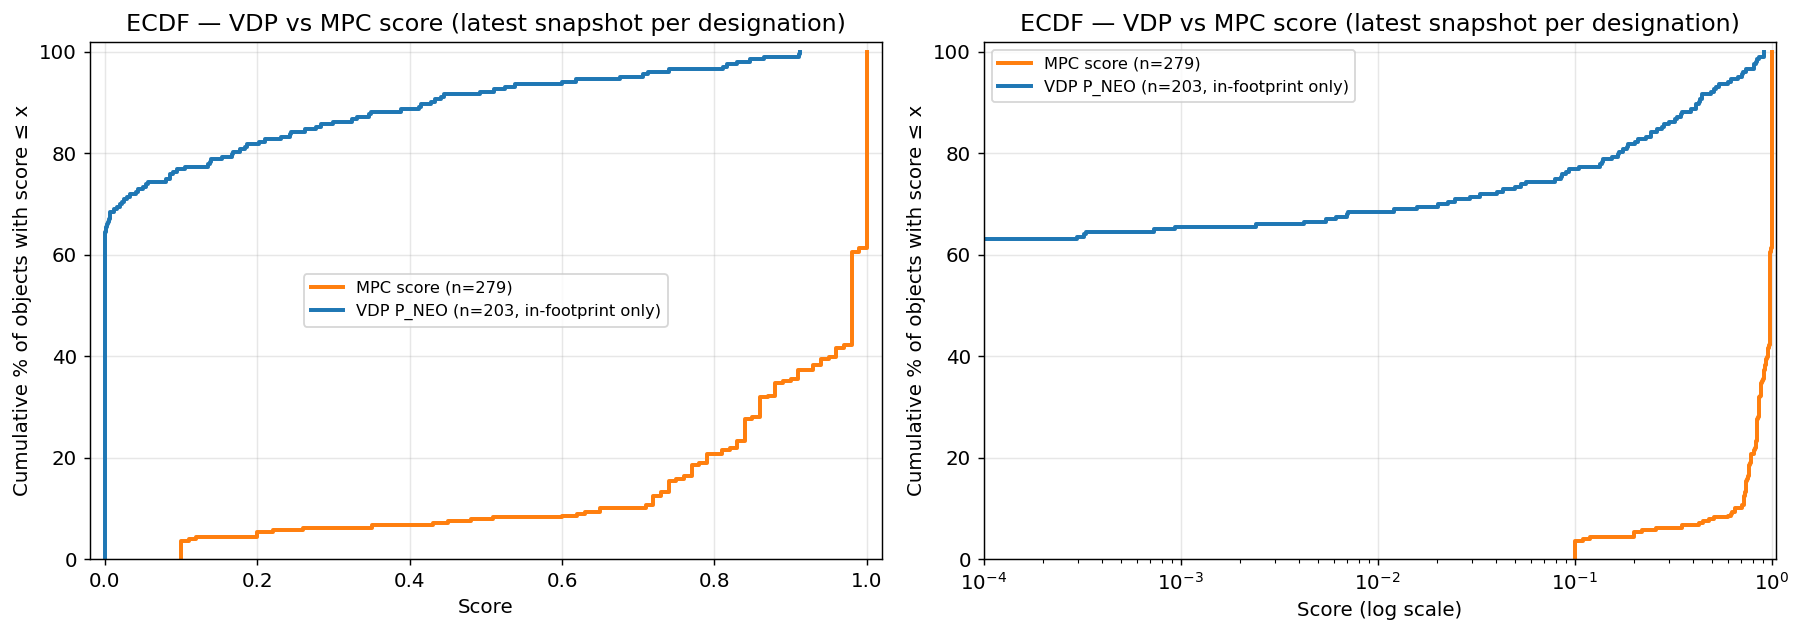

In [9]:
def ecdf(x):
    xs = np.sort(x[np.isfinite(x)])
    ys = np.arange(1, len(xs) + 1) / len(xs)
    return xs, ys

mpc_scores = latest['score_0_1'].dropna().to_numpy()
vdp_scores = latest.loc[latest['P_NEO_vdp'].notna(), 'P_NEO_vdp'].to_numpy()

xs_mpc, ys_mpc = ecdf(mpc_scores)
xs_vdp, ys_vdp = ecdf(vdp_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, xscale in zip(axes, ['linear', 'log']):
    ax.step(xs_mpc, ys_mpc * 100, where='post', lw=2.2, color='tab:orange',
            label=f'MPC score (n={len(xs_mpc)})')
    ax.step(xs_vdp, ys_vdp * 100, where='post', lw=2.2, color='tab:blue',
            label=f'VDP P_NEO (n={len(xs_vdp)}, in-footprint only)')
    ax.set_xscale(xscale)
    if xscale == 'log':
        ax.set_xlim(1e-4, 1.05)
    else:
        ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(0, 102)
    ax.set_xlabel('Score' + (' (log scale)' if xscale == 'log' else ''))
    ax.set_ylabel('Cumulative % of objects with score ≤ x')
    ax.set_title('ECDF — VDP vs MPC score (latest snapshot per designation)')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/neocp_ecdf.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

## 9. MPC score over time

One line per designation. MPC score typically rises as the arc length grows
and the orbit is better constrained. Objects that drop off quickly were
either confirmed NEOs (promoted) or identified as known MBAs (removed).

Showing 30 designations (score std ≥ 0.08, ≥5 snaps)


/tmp/ipykernel_2489577/2977938973.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(active_desigs))


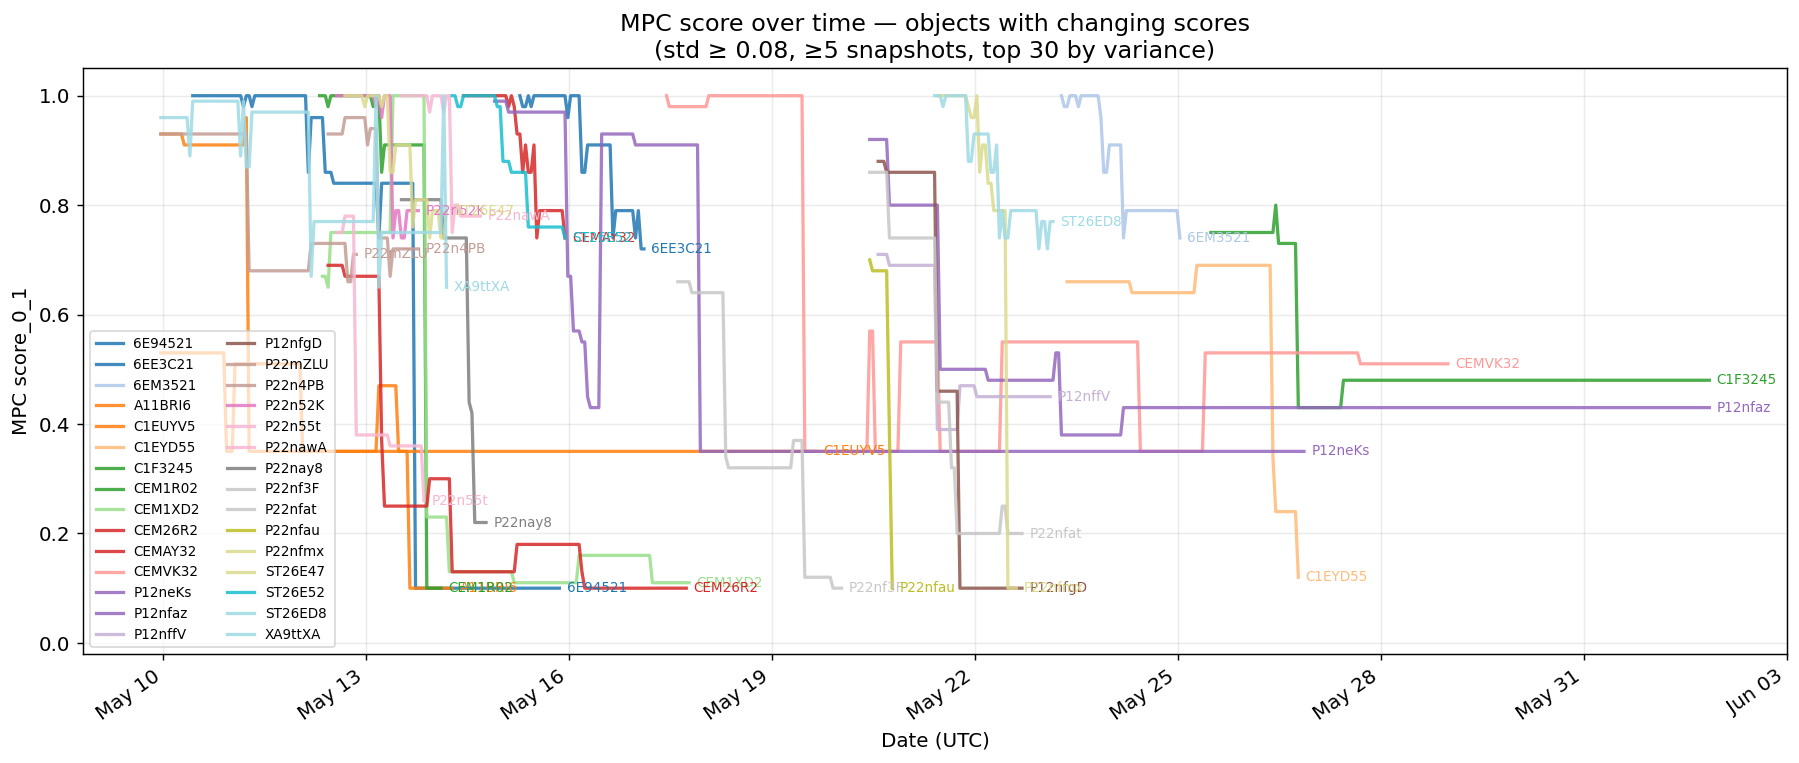

In [10]:

# Show only objects whose MPC score changed noticeably (std > 0.08)
# and appeared for at least MIN_SNAPS snapshots — keeps the plot readable.
MIN_SNAPS  = 5
MIN_STD    = 0.08     # score must vary by at least this much to be interesting
MAX_LINES  = 30       # cap at 30 lines

snap_counts  = final.groupby('designation')['snapshot_id'].nunique()
score_std    = final.groupby('designation')['score_0_1'].std().fillna(0)

active_desigs = (
    snap_counts[snap_counts >= MIN_SNAPS].index
    .intersection(score_std[score_std >= MIN_STD].index)
    .tolist()
)

# If still too many, keep the ones with highest score variance
if len(active_desigs) > MAX_LINES:
    active_desigs = (
        score_std.loc[active_desigs]
        .nlargest(MAX_LINES).index.tolist()
    )

print(f'Showing {len(active_desigs)} designations (score std ≥ {MIN_STD}, ≥{MIN_SNAPS} snaps)')

plot_df = final[final['designation'].isin(active_desigs)].copy()
plot_df = plot_df.sort_values('fetched_at_utc')

cmap = cm.get_cmap('tab20', len(active_desigs))

fig, ax = plt.subplots(figsize=(14, 6))

for i, desig in enumerate(sorted(active_desigs)):
    grp = plot_df[plot_df['designation'] == desig]
    ax.plot(grp['fetched_at_utc'], grp['score_0_1'],
            lw=1.8, alpha=0.85, color=cmap(i), label=desig)
    last = grp.iloc[-1]
    ax.annotate(desig, xy=(last['fetched_at_utc'], last['score_0_1']),
                xytext=(4, 0), textcoords='offset points',
                fontsize=7.5, color=cmap(i), va='center')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=35, ha='right')
ax.set_ylim(-0.02, 1.05)
ax.set_xlabel('Date (UTC)')
ax.set_ylabel('MPC score_0_1')
ax.set_title(f'MPC score over time — objects with changing scores\n'
             f'(std ≥ {MIN_STD}, ≥{MIN_SNAPS} snapshots, top {MAX_LINES} by variance)')
ax.legend(fontsize=7.5, ncol=2, loc='lower left', framealpha=0.7)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('outputs/neocp_mpc_score_time.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)


## 10. VDP score over time (in-footprint objects)

Unlike MPC score, VDP depends only on instantaneous sky position + apparent velocity,
not arc length. Scores should be near-constant per designation unless the object moves
across the map boundary or has an unusual velocity trajectory.

Showing 25 in-footprint designations


/tmp/ipykernel_2489577/2974357.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('tab20', len(fp_active))


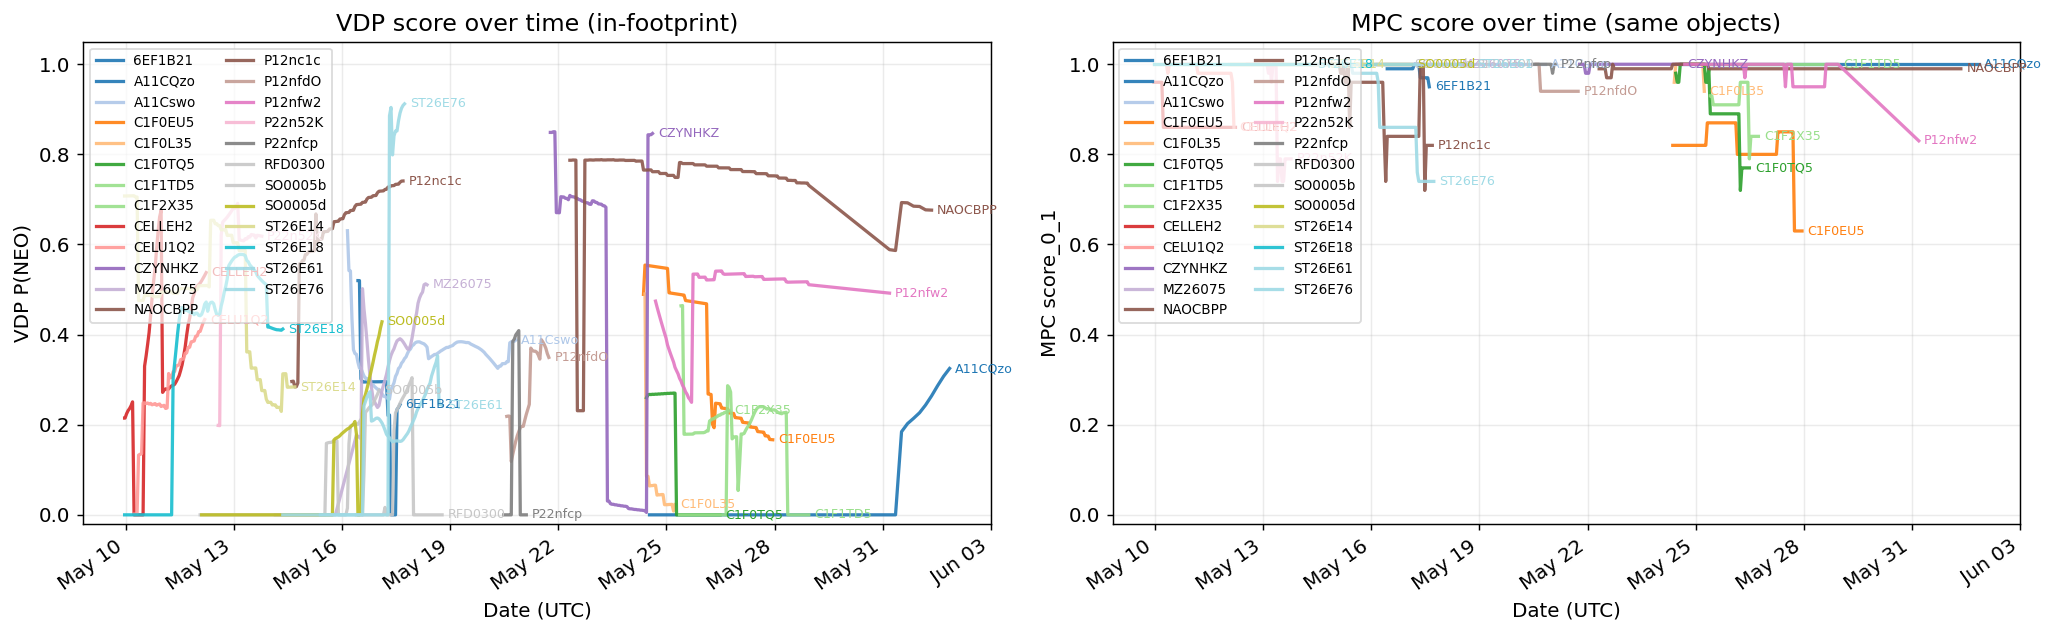

In [11]:

# VDP time series: in-footprint objects only, capped at MAX_LINES by VDP score range
MAX_VDP_LINES = 25

fp_df = final[final['P_NEO_vdp'].notna()].copy()
fp_snaps = fp_df.groupby('designation')['snapshot_id'].nunique()
fp_range = (fp_df.groupby('designation')['P_NEO_vdp'].max()
            - fp_df.groupby('designation')['P_NEO_vdp'].min())

fp_active = fp_snaps[fp_snaps >= MIN_SNAPS].index.tolist()

# Sort by VDP score range (most variable first), then take top N
if len(fp_active) > MAX_VDP_LINES:
    fp_active = (
        fp_range.loc[fp_active]
        .nlargest(MAX_VDP_LINES).index.tolist()
    )

if not fp_active:
    print(f'No in-footprint designations with ≥{MIN_SNAPS} snapshots.')
else:
    print(f'Showing {len(fp_active)} in-footprint designations')
    cmap2 = cm.get_cmap('tab20', len(fp_active))
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, ycol, ylabel, title in [
        (axes[0], 'P_NEO_vdp', 'VDP P(NEO)',    'VDP score over time (in-footprint)'),
        (axes[1], 'score_0_1', 'MPC score_0_1',  'MPC score over time (same objects)'),
    ]:
        for i, desig in enumerate(sorted(fp_active)):
            grp = fp_df[fp_df['designation'] == desig].sort_values('fetched_at_utc')
            ax.plot(grp['fetched_at_utc'], grp[ycol],
                    lw=1.8, alpha=0.9, color=cmap2(i), label=desig)
            last = grp.iloc[-1]
            ax.annotate(desig, xy=(last['fetched_at_utc'], last[ycol]),
                        xytext=(3, 0), textcoords='offset points',
                        fontsize=7, color=cmap2(i), va='center')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right')
        ax.set_ylim(-0.02, 1.05)
        ax.set_xlabel('Date (UTC)')
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(fontsize=7.5, ncol=2, loc='upper left', framealpha=0.7)
        ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig('outputs/neocp_vdp_score_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)


## 11. VDP vs MPC direct scatter

One point per (designation, snapshot) for in-footprint objects. Threshold lines at
VDP ≈ 0.028 (S3M best-F1) and MPC = 0.65 (Wagg NEOCP submission threshold).
The four quadrants show classifier agreement and disagreement.

/tmp/ipykernel_2489577/2655796689.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap3 = cm.get_cmap('tab20', len(desig_list))


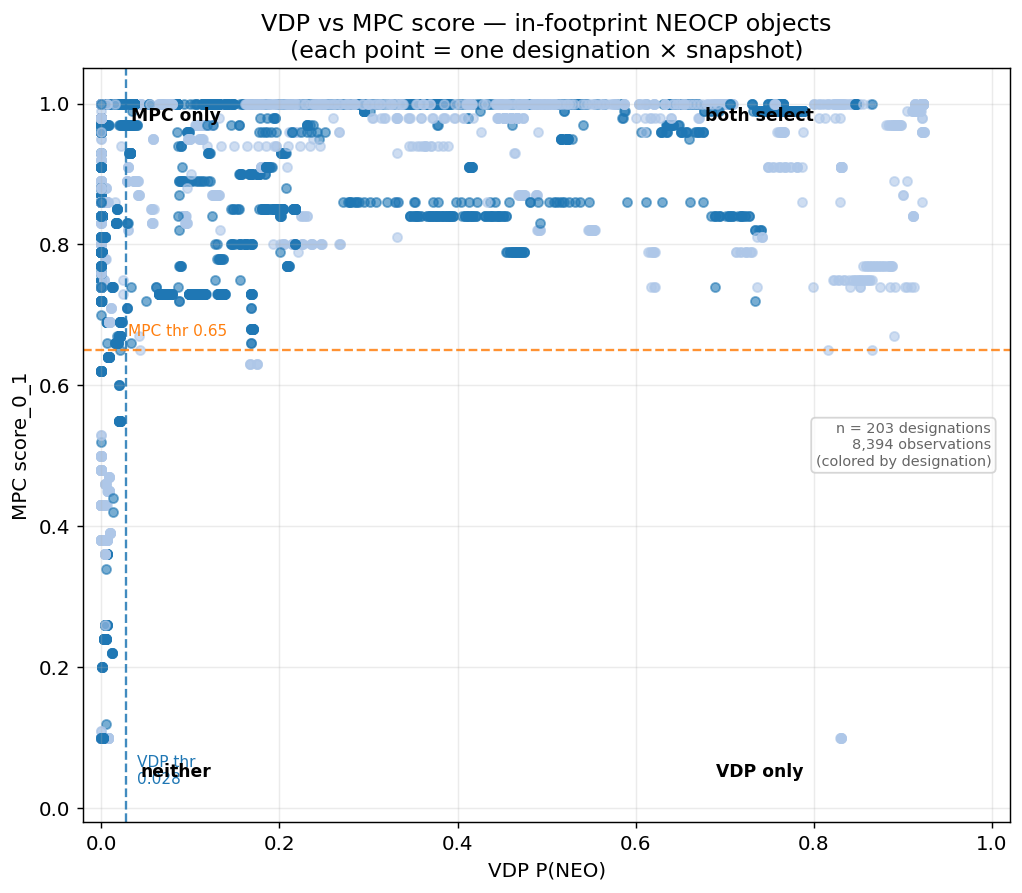

In [12]:

fp_all = final[final['P_NEO_vdp'].notna()].copy()

VDP_THR = 0.028
MPC_THR = 0.65

desig_list = sorted(fp_all['designation'].unique())
cmap3 = cm.get_cmap('tab20', len(desig_list))

fig, ax = plt.subplots(figsize=(8, 7))

for i, desig in enumerate(desig_list):
    sub = fp_all[fp_all['designation'] == desig]
    ax.scatter(sub['P_NEO_vdp'], sub['score_0_1'],
               s=25, alpha=0.6, color=cmap3(i % 20),
               rasterized=True)

# threshold lines
ax.axvline(VDP_THR, color='tab:blue',   lw=1.3, linestyle='--', alpha=0.85)
ax.axhline(MPC_THR, color='tab:orange', lw=1.3, linestyle='--', alpha=0.85)
ax.text(VDP_THR + 0.012, 0.03, f'VDP thr\n{VDP_THR}',
        color='tab:blue', fontsize=8.5, va='bottom')
ax.text(0.03, MPC_THR + 0.02, f'MPC thr {MPC_THR}',
        color='tab:orange', fontsize=8.5)

# quadrant labels — placed well inside each region
ax.text(0.73, 0.93, 'both select',  transform=ax.transAxes, ha='center', fontsize=9.5, fontweight='bold')
ax.text(0.10, 0.93, 'MPC only',     transform=ax.transAxes, ha='center', fontsize=9.5, fontweight='bold')
ax.text(0.73, 0.06, 'VDP only',     transform=ax.transAxes, ha='center', fontsize=9.5, fontweight='bold')
ax.text(0.10, 0.06, 'neither',      transform=ax.transAxes, ha='center', fontsize=9.5, fontweight='bold')

# single summary annotation instead of per-designation legend
ax.text(0.98, 0.50,
        f'n = {len(desig_list)} designations\n{len(fp_all):,} observations\n(colored by designation)',
        transform=ax.transAxes, ha='right', va='center',
        fontsize=8, color='0.4',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.8', alpha=0.8))

ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.05)
ax.set_xlabel('VDP P(NEO)')
ax.set_ylabel('MPC score_0_1')
ax.set_title('VDP vs MPC score — in-footprint NEOCP objects\n'
             '(each point = one designation × snapshot)')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('outputs/neocp_vdp_vs_mpc_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)


## 12. Velocity-space view (in-footprint objects)

Where do VDP-scored NEOCP objects sit in (vlam, vbeta) space?
Objects outside the grid (beyond ±1.5 deg/day) receive P_NEO = 0.

## 13. Which objects left the NEOCP — and were they confirmed NEOs?

Objects disappear from NEOCP in two ways:
- **Confirmed / promoted**: got a provisional designation → real discovery (likely NEO)
- **Identified as known**: recognised as a known MBA/etc → removed

Heuristic from MPC scoring: score drops to ~0.10 when MPC identifies the object as non-NEO.
We query the MPC NEOCP history page for each disappeared designation to check the official outcome.


In [13]:

import urllib.request, urllib.parse, re, time

# ── 1. Identify gone objects ───────────────────────────────────────────────
snap_counts = obj.groupby('designation')['snapshot_id'].nunique()
last_seen   = obj.groupby('designation')['fetched_at_utc'].max()
last_score  = obj.sort_values('fetched_at_utc').groupby('designation')['score_0_1'].last()

latest_snapshot_id = obj.snapshot_id.iloc[-1]
still_on = set(obj[obj.snapshot_id == latest_snapshot_id].designation)
gone     = sorted(set(obj.designation.unique()) - still_on,
                  key=lambda d: last_seen[d])

gone_df = pd.DataFrame({
    'designation': gone,
    'last_seen':   [last_seen[d] for d in gone],
    'n_snaps':     [snap_counts[d] for d in gone],
    'final_score': [last_score[d]  for d in gone],
})

# Heuristic disposition from final score:
#   score ≤ 0.15 → MPC identified as non-NEO (known MBA/etc.)
#   score ≥ 0.90 → likely confirmed NEO or still uncertain
gone_df['heuristic'] = gone_df.final_score.apply(
    lambda s: 'known_non-NEO' if s <= 0.15 else ('likely_NEO?' if s >= 0.90 else 'uncertain')
)

print(f"Total gone: {len(gone_df)}")
print(gone_df.heuristic.value_counts().to_string())
print()
print("Likely confirmed NEOs (final_score ≥ 0.90, multiple snapshots):")
candidates = gone_df[(gone_df.final_score >= 0.90) & (gone_df.n_snaps >= 10)].sort_values('n_snaps', ascending=False)
print(candidates.to_string(index=False))


Total gone: 267
heuristic
likely_NEO?      172
uncertain         83
known_non-NEO     12

Likely confirmed NEOs (final_score ≥ 0.90, multiple snapshots):
designation                        last_seen  n_snaps  final_score   heuristic
    NAOCAN7 2026-05-28 23:48:44.142240+00:00      238         1.00 likely_NEO?
    ST26EC8 2026-05-28 23:48:44.142240+00:00      202         0.98 likely_NEO?
    NAOCBPP 2026-06-01 08:34:21.013229+00:00      169         0.99 likely_NEO?
    ST26E75 2026-05-21 19:42:13.437223+00:00      155         0.98 likely_NEO?
    CEMAUH2 2026-05-20 19:41:37.394968+00:00      153         1.00 likely_NEO?
    ST26EC7 2026-05-26 16:45:14.728988+00:00      147         0.98 likely_NEO?
    C1EYPU5 2026-05-31 04:34:06.977176+00:00      135         1.00 likely_NEO?
    ST26ED1 2026-05-26 16:45:14.728988+00:00      131         0.98 likely_NEO?
    TF26EE0 2026-05-25 17:44:37.714667+00:00      122         1.00 likely_NEO?
    SO0005d 2026-05-17 02:35:41.372426+00:00      121   

In [14]:

# ── 2. Classify disposition from score trajectory ─────────────────────────
# MPC's convention:
#   Score drops to ~10 right before removal → identified as known non-NEO
#   Score stays high (≥ 0.90) throughout → confirmed/promoted (likely NEO discovery)
#
# Use the MINIMUM score ever seen (not just final) as the cleaner signal —
# if the score ever tanked, MPC had doubts and eventually removed it as non-NEO.

min_score  = obj.groupby('designation')['score_0_1'].min()
max_score  = obj.groupby('designation')['score_0_1'].max()
mean_score = obj.groupby('designation')['score_0_1'].mean()

gone_df['min_score']  = gone_df.designation.map(min_score)
gone_df['max_score']  = gone_df.designation.map(max_score)
gone_df['mean_score'] = gone_df.designation.map(mean_score)
gone_df['score_drop'] = gone_df.max_score - gone_df.final_score  # how much it fell at the end

# Disposition:
# - final_score ≤ 0.15          → MPC identified as non-NEO  (score tank = known MBA etc.)
# - final_score ≥ 0.90 AND
#   min_score   ≥ 0.70 AND
#   n_snaps     ≥ 5             → likely confirmed NEO discovery
# - everything else             → uncertain / insufficient data

def classify(row):
    if row.final_score <= 0.15:
        return 'non-NEO (identified)'
    if row.final_score >= 0.90 and row.min_score >= 0.70 and row.n_snaps >= 5:
        return 'likely NEO confirmation'
    return 'uncertain'

gone_df['disposition'] = gone_df.apply(classify, axis=1)

print("Disposition summary:")
print(gone_df.disposition.value_counts().to_string())
print()

neo_confirmed = gone_df[gone_df.disposition == 'likely NEO confirmation'].sort_values('n_snaps', ascending=False)
non_neo       = gone_df[gone_df.disposition == 'non-NEO (identified)'].sort_values('n_snaps', ascending=False)

print(f"Likely confirmed NEOs ({len(neo_confirmed)}):")
print(neo_confirmed[['designation','first_seen','last_seen','n_snaps',
                      'min_score','final_score']].to_string(index=False))
print()
print(f"Confirmed non-NEOs ({len(non_neo)}) — these are the ground-truth negatives:")
print(non_neo[['designation','n_snaps','max_score','final_score']].to_string(index=False))


Disposition summary:
disposition
likely NEO confirmation    140
uncertain                  115
non-NEO (identified)        12

Likely confirmed NEOs (140):


KeyError: "['first_seen'] not in index"

In [ ]:

# ── 3. VDP vs digest2 score trajectory for confirmed/non-NEO objects ───────
# This is the key validation: did VDP and digest2 score the right objects
# correctly BEFORE MPC made the call?

# Join disposition back to final scored dataframe
disp_map = gone_df.set_index('designation')['disposition']
final['disposition'] = final['designation'].map(disp_map).fillna(
    'still on NEOCP' if False else 'current/uncertain'
)

# Focus on objects with confirmed disposition AND VDP score
labelled = final[
    final['disposition'].isin(['likely NEO confirmation', 'non-NEO (identified)']) &
    final['P_NEO_vdp'].notna()
].copy()

if len(labelled) == 0:
    print("No labelled objects with VDP scores in footprint — "
          "check map coverage for these designations.")
    print("Designated non-NEOs:", non_neo.designation.tolist())
    print("Designated NEOs:",     neo_confirmed.designation.tolist())
else:
    # Summary: median VDP and MPC score per disposition
    print("Median scores by ground-truth disposition (in-footprint only):")
    print(labelled.groupby('disposition')[['score_0_1','P_NEO_vdp']].median().round(3))
    print()

    # Plot score trajectories for each disposition class
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    colors = {'likely NEO confirmation': 'tab:blue', 'non-NEO (identified)': 'tab:red'}

    for ax, ycol, ylabel in [
        (axes[0], 'P_NEO_vdp', 'VDP P(NEO)'),
        (axes[1], 'score_0_1', 'MPC score_0_1'),
    ]:
        for disp, grp in labelled.groupby('disposition'):
            for desig, dgrp in grp.groupby('designation'):
                dgrp = dgrp.sort_values('fetched_at_utc')
                ax.plot(dgrp['fetched_at_utc'], dgrp[ycol],
                        color=colors[disp], lw=1.5, alpha=0.7)
            # legend proxy
            ax.plot([], [], color=colors[disp], lw=2.5, label=disp)

        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right')
        ax.set_ylim(-0.02, 1.05)
        ax.set_xlabel('Date (UTC)')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{ylabel} — confirmed NEOs vs non-NEOs (in-footprint)')
        ax.legend(fontsize=9); ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig('outputs/neocp_confirmed_trajectories.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)


In [ ]:
fp_latest = latest[latest['P_NEO_vdp'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in [
    (axes[0], 'P_NEO_vdp', 'VDP P(NEO)'),
    (axes[1], 'score_0_1', 'MPC score_0_1'),
]:
    sc = ax.scatter(fp_latest['vlam'], fp_latest['vbeta'],
                    c=fp_latest[col], cmap='plasma', vmin=0, vmax=1,
                    s=60, alpha=0.85)
    fig.colorbar(sc, ax=ax, label=label)
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
    ax.axvline(0, color='k', lw=0.5, alpha=0.3)
    ax.axhline(0, color='k', lw=0.5, alpha=0.3)
    ax.set_xlabel('v_lambda (deg/day)')
    ax.set_ylabel('v_beta (deg/day)')
    ax.set_title(f'Velocity space — color = {label}')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('outputs/neocp_velocity_space.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

## 14. digest2 validation: Hyak real binary vs MPC score

Validation run on Hyak (2026-06-08) using `neomod/pipeline/validate_digest2_neocp.py`:
for each NEOCP object with ephemeris data, two consecutive hourly positions were
formatted as MPC 80-column observations and scored with the real `mpcdev-digest2`
binary — the same binary used for `P_NEO_d2` in the Sorcha comparison.

Results are loaded from `outputs/validate_digest2_neocp.csv` (17 objects from the
May 7 2026 ephemeris snapshot). MPC's `score_0_1` comes from the NEOCP history table.

Residual scatter is expected: MPC used the full submitted arc (2–35 observations);
we used synthetic 1-hr tracklets from ephemerides. The ordering at the extremes
(high-MPC → high ours; low-MPC → low ours) validates the binary is functioning correctly.

In [ ]:
# Load Hyak real-binary digest2 validation results
# Produced by: neomod/pipeline/validate_digest2_neocp.py (Hyak, 2026-06-08)
# Binary: mpcdev-digest2 — same binary used for Sorcha P_NEO_d2

d2_val = pd.read_csv('outputs/validate_digest2_neocp.csv')
print(f"Loaded {len(d2_val)} objects from Hyak digest2 validation")
print(f"Columns: {list(d2_val.columns)}")
print()
print(d2_val[['designation', 'mpc_score_0_1', 'our_d2_score', 'nobs', 'arc_days']].to_string(index=False))

In [ ]:
# Merge validation scores into fp_score (in-footprint objects, latest snapshot)
fp_score = latest[latest['P_NEO_vdp'].notna()].copy()

fp_score = fp_score.merge(
    d2_val[['designation', 'our_d2_score']].rename(columns={'our_d2_score': 'P_NEO_d2_ours'}),
    on='designation',
    how='left'
)

n_total   = len(fp_score)
n_matched = fp_score['P_NEO_d2_ours'].notna().sum()
print(f"In-footprint objects (latest snapshot): {n_total}")
print(f"With Hyak d2 validation score:          {n_matched}")
print()
validated = fp_score.dropna(subset=['P_NEO_d2_ours'])
print(f"P_NEO_d2_ours : {validated['P_NEO_d2_ours'].min():.3f} – {validated['P_NEO_d2_ours'].max():.3f}")
print(f"MPC score_0_1 : {validated['score_0_1'].min():.3f} – {validated['score_0_1'].max():.3f}")
print(f"VDP P_NEO     : {validated['P_NEO_vdp'].min():.3f} – {validated['P_NEO_vdp'].max():.3f}")

In [ ]:
def _spearman(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        return float('nan')
    rx = np.argsort(np.argsort(x[mask])).astype(float)
    ry = np.argsort(np.argsort(y[mask])).astype(float)
    return float(np.corrcoef(rx, ry)[0, 1])

x_d2  = fp_score['P_NEO_d2_ours'].to_numpy(float)  # NaN for unvalidated objects
x_vdp = fp_score['P_NEO_vdp'].to_numpy(float)
x_mpc = fp_score['score_0_1'].to_numpy(float)

n_d2 = np.isfinite(x_d2).sum()

r_d2_mpc  = _spearman(x_d2,  x_mpc)
r_vdp_mpc = _spearman(x_vdp, x_mpc)
r_d2_vdp  = _spearman(x_d2,  x_vdp)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── left: Hyak d2 vs MPC (validated subset only) ─────────────────────────────
ax = axes[0]
d2_mask = np.isfinite(x_d2) & np.isfinite(x_mpc)
sc = ax.scatter(x_d2[d2_mask], x_mpc[d2_mask],
                c=x_vdp[d2_mask], cmap='plasma', vmin=0, vmax=1,
                s=60, alpha=0.9, edgecolors='k', linewidths=0.4)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.35)
fig.colorbar(sc, ax=ax, label='VDP P(NEO)')
ax.set_xlabel('Hyak real digest2 P(NEO)')
ax.set_ylabel('MPC score_0_1')
ax.set_title(f'Hyak d2 vs MPC  (N={n_d2})\nSpearman r = {r_d2_mpc:.2f}')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.05)
ax.grid(alpha=0.25)

# ── middle: VDP vs MPC (all in-footprint) ─────────────────────────────────────
ax = axes[1]
sc2 = ax.scatter(x_vdp, x_mpc,
                 c=x_d2, cmap='viridis', vmin=0, vmax=1,
                 s=40, alpha=0.7, edgecolors='none')
fig.colorbar(sc2, ax=ax, label='Hyak d2')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.35)
ax.set_xlabel('VDP P(NEO)')
ax.set_ylabel('MPC score_0_1')
ax.set_title(f'VDP vs MPC  (N={len(x_vdp)})\nSpearman r = {r_vdp_mpc:.2f}')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.05)
ax.grid(alpha=0.25)

# ── right: ECDF all three ─────────────────────────────────────────────────────
ax = axes[2]
for x, label, color in [
    (x_vdp, f'VDP P(NEO)  (n={np.isfinite(x_vdp).sum()})', 'tab:blue'),
    (x_d2,  f'Hyak d2  (n={n_d2})',                         'tab:orange'),
    (x_mpc, f'MPC digest2  (n={np.isfinite(x_mpc).sum()})', 'tab:green'),
]:
    xs = np.sort(x[np.isfinite(x)])
    ys = np.arange(1, len(xs) + 1) / len(xs)
    ax.step(xs, ys, label=label, color=color, lw=2)
ax.set_xlabel('Score / P(NEO)')
ax.set_ylabel('CDF')
ax.set_title('Score distributions\n(in-footprint objects, latest snapshot)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

print(f"Spearman r: Hyak_d2 vs MPC = {r_d2_mpc:.2f}  |  "
      f"VDP vs MPC = {r_vdp_mpc:.2f}  |  Hyak_d2 vs VDP = {r_d2_vdp:.2f}")

plt.suptitle('digest2 validation — Hyak real binary vs MPC published score',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('outputs/neocp_d2_validation.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)